In [3]:
# Install all required dependencies
!pip install numpy pandas matplotlib seaborn scikit-learn xgboost joblib imblearn
%pip install shap

Defaulting to user installation because normal site-packages is not writeable
  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
   ---------------------------------------- 0.0/39.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/39.2 MB ? eta -:--:--
    --------------------------------------- 0.5/39.2 MB 910.8 kB/s eta 0:00:43
    --------------------------------------- 0.8/39.2 MB 997.0 kB/s eta 0:00:39
   - -------------------------------------- 1.0/39.2 MB 1.1 MB/s eta 0:00:34
   - -------------------------------------- 1.3/39.2 MB 1.2 MB/s eta 0:00:33
   - -----------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (accuracy_score, classification_report,confusion_matrix, ConfusionMatrixDisplay,roc_auc_score, roc_curve,precision_recall_curve, average_precision_score)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import joblib
import os
from pathlib import Path
import warnings
import shap
warnings.filterwarnings('ignore')

c:\Users\prana\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load & Inspect Data

In [5]:
path = Path.cwd().parent / 'Data' / 'Telco-Customer-Churn.csv'
print(path)

d:\VSCode\Projects\telecom-churn-prediction\Data\Telco-Customer-Churn.csv


In [6]:
data = pd.read_csv(path)
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
data.drop('customerID', axis=1, inplace=True)
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

## 3. Preprocessing

In [9]:
# Convert TotalCharges to numeric and drop nulls
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data = data.dropna()
print(f"Shape after cleaning: {data.shape}")

Shape after cleaning: (7032, 20)


In [10]:
# Label encode all categorical columns
categorical_cols = data.select_dtypes(include=['object', 'category']).columns
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


## 4. Exploratory Data Analysis

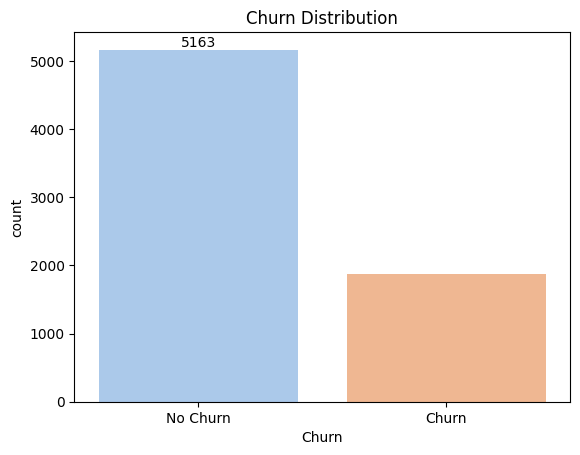

Churn
No Churn    0.734215
Churn       0.265785
Name: proportion, dtype: float64


In [11]:
# Churn distribution
ax = sns.countplot(x='Churn', data=data, palette='pastel')
ax.bar_label(ax.containers[0])
plt.title("Churn Distribution")
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.show()
print(data['Churn'].value_counts(normalize=True).rename({0: 'No Churn', 1: 'Churn'}))

In [12]:
# Correlation with Churn
correlation_matrix = data.corr()
print(correlation_matrix['Churn'].sort_values(ascending=False))

Churn               1.000000
MonthlyCharges      0.192858
PaperlessBilling    0.191454
SeniorCitizen       0.150541
PaymentMethod       0.107852
MultipleLines       0.038043
PhoneService        0.011691
gender             -0.008545
StreamingTV        -0.036303
StreamingMovies    -0.038802
InternetService    -0.047097
Partner            -0.149982
Dependents         -0.163128
DeviceProtection   -0.177883
OnlineBackup       -0.195290
TotalCharges       -0.199484
TechSupport        -0.282232
OnlineSecurity     -0.289050
tenure             -0.354049
Contract           -0.396150
Name: Churn, dtype: float64


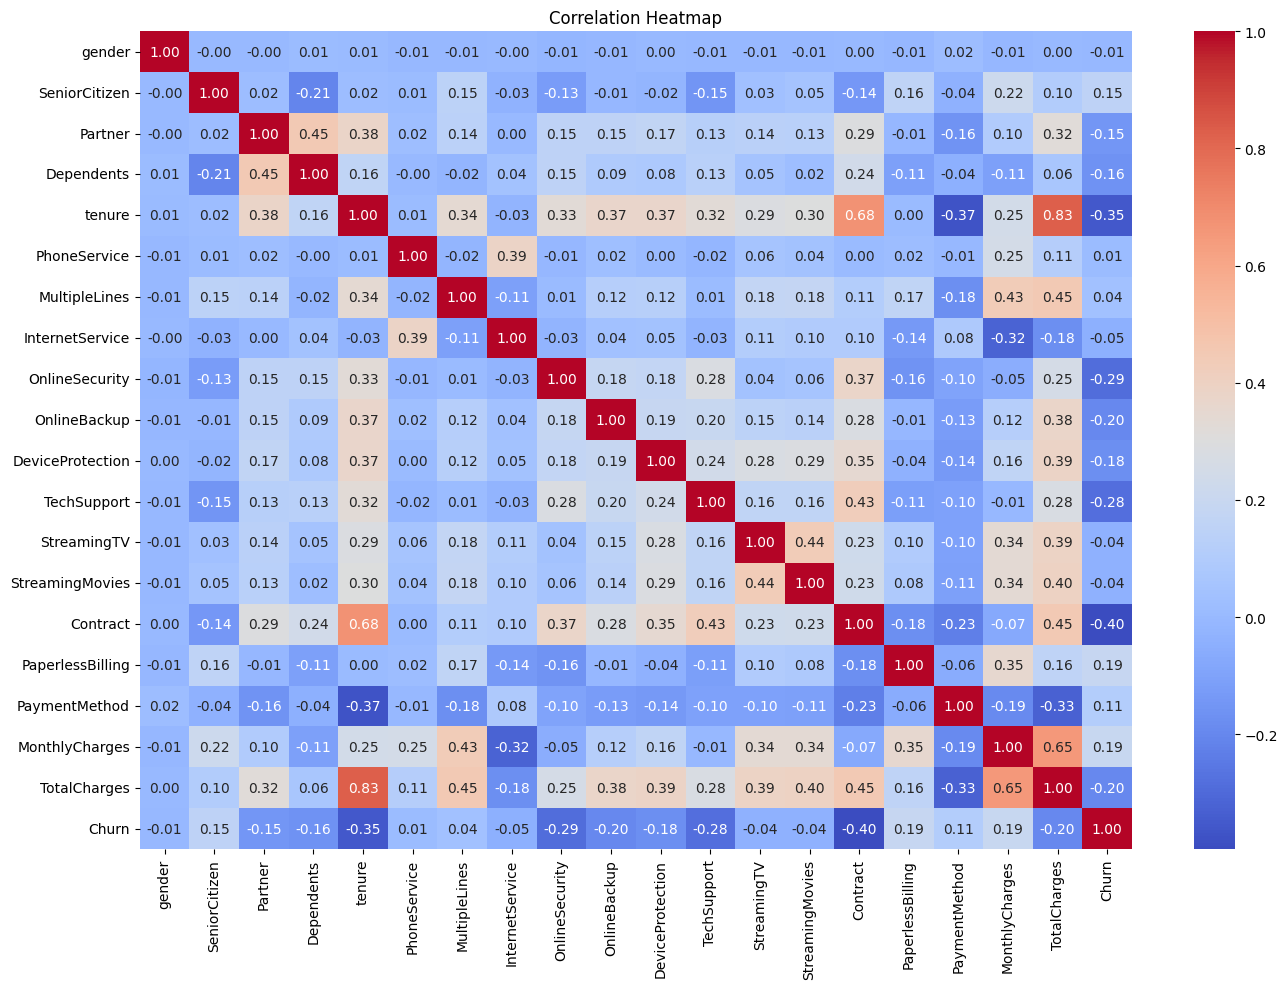

In [13]:
# Full correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 5. Feature Selection via Random Forest

In [14]:
X = data.drop('Churn', axis=1)
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_train, y_train)

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_selector.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

             Feature  Importance
18      TotalCharges    0.184953
17    MonthlyCharges    0.178014
4             tenure    0.154510
14          Contract    0.080585
16     PaymentMethod    0.052031
8     OnlineSecurity    0.048509
11       TechSupport    0.047581
7    InternetService    0.026813
0             gender    0.026715
9       OnlineBackup    0.025883
15  PaperlessBilling    0.025652
2            Partner    0.023329
6      MultipleLines    0.022613
10  DeviceProtection    0.021107
1      SeniorCitizen    0.020989
3         Dependents    0.019778
12       StreamingTV    0.017974
13   StreamingMovies    0.017569
5       PhoneService    0.005397


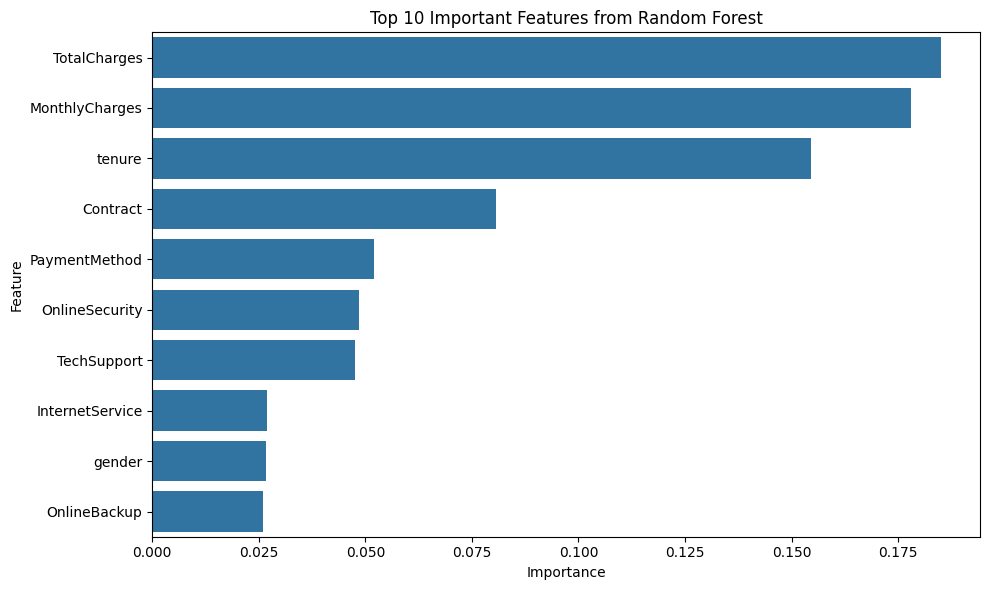

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title("Top 10 Important Features from Random Forest")
plt.tight_layout()
plt.show()

In [16]:
# Reduce to top 10 features
important_features = feature_importance_df.head(10)['Feature'].tolist()
df_reduced = data[important_features + ['Churn']]

X = df_reduced.drop('Churn', axis=1)
y = df_reduced['Churn']

print("Selected features:", important_features)

Selected features: ['TotalCharges', 'MonthlyCharges', 'tenure', 'Contract', 'PaymentMethod', 'OnlineSecurity', 'TechSupport', 'InternetService', 'gender', 'OnlineBackup']


## 6. Baseline Model Comparison

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB()
}

for name, model in models.items():
    X_input = X_scaled if name in ["Logistic Regression", "SVM", "Naive Bayes"] else X
    scores = cross_val_score(model, X_input, y, cv=5, scoring='accuracy')
    print(f"{name}: Mean Accuracy = {scores.mean():.4f}")

Logistic Regression: Mean Accuracy = 0.7949
Random Forest: Mean Accuracy = 0.7797
XGBoost: Mean Accuracy = 0.7817
SVM: Mean Accuracy = 0.7932
Naive Bayes: Mean Accuracy = 0.7517


## 7. Hyperparameter Tuning

In [18]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2'],
    'class_weight': ['balanced']
}

grid_lr = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_lr, cv=5, scoring='f1')
grid_lr.fit(X_scaled, y)

print("Best Logistic Regression Params:", grid_lr.best_params_)
print("Best F1 Score:", grid_lr.best_score_)

Best Logistic Regression Params: {'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
Best F1 Score: 0.6147774768630316


In [19]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced']
}

grid_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, cv=5, scoring='f1')
grid_rf.fit(X, y)

print("Best Random Forest Params:", grid_rf.best_params_)
print("Best F1 Score:", grid_rf.best_score_)

Best Random Forest Params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best F1 Score: 0.6231938923897683


In [20]:
scale_pos_weight = y.value_counts()[0] / y.value_counts()[1]

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

grid_xgb = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_pos_weight),
    param_grid_xgb, cv=5, scoring='f1'
)
grid_xgb.fit(X, y)

print("Best XGBoost Params:", grid_xgb.best_params_)
print("Best F1 Score:", grid_xgb.best_score_)

Best XGBoost Params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
Best F1 Score: 0.631776956685011


## 8. Handling Class Imbalance with SMOTE

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_smote).value_counts().to_dict())

Before SMOTE: {0: 4130, 1: 1495}
After SMOTE:  {1: 4130, 0: 4130}


In [22]:
# Cross-val scores on SMOTE data
lr_model = LogisticRegression(**grid_lr.best_params_)
scores = cross_val_score(lr_model, X_train_smote, y_train_smote, cv=5, scoring='f1')
print(f"Logistic Regression (SMOTE) F1 Score: {scores.mean():.4f}")

rf_model = RandomForestClassifier(**grid_rf.best_params_)
scores = cross_val_score(rf_model, X_train_smote, y_train_smote, cv=5, scoring='f1')
print(f"Random Forest (SMOTE) F1 Score: {scores.mean():.4f}")

Logistic Regression (SMOTE) F1 Score: 0.7957
Random Forest (SMOTE) F1 Score: 0.8324


## 9. Ensemble: Voting Classifier

In [23]:
voting_clf = VotingClassifier(estimators=[
    ('rf', RandomForestClassifier(**grid_rf.best_params_)),
    ('lr', LogisticRegression(**grid_lr.best_params_)),
    ('xgb', XGBClassifier(**grid_xgb.best_params_, use_label_encoder=False, eval_metric='logloss'))
], voting='soft')

voting_clf.fit(X_train_smote, y_train_smote)
y_pred = voting_clf.predict(X_test)
y_prob = voting_clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.88      0.76      0.82      1033
       Churn       0.52      0.72      0.61       374

    accuracy                           0.75      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.75      0.76      1407



## 10. Evaluation Metrics

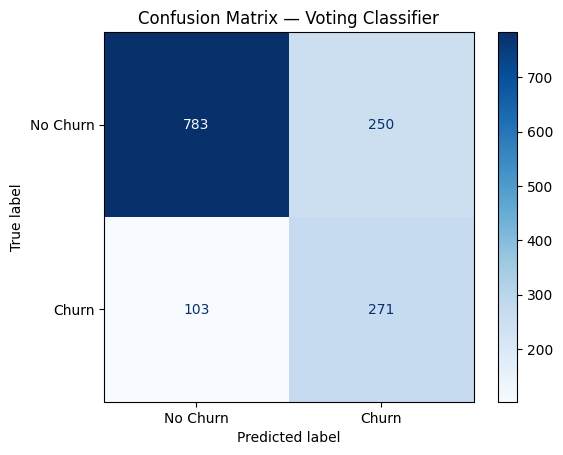

In [24]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Voting Classifier")
plt.show()

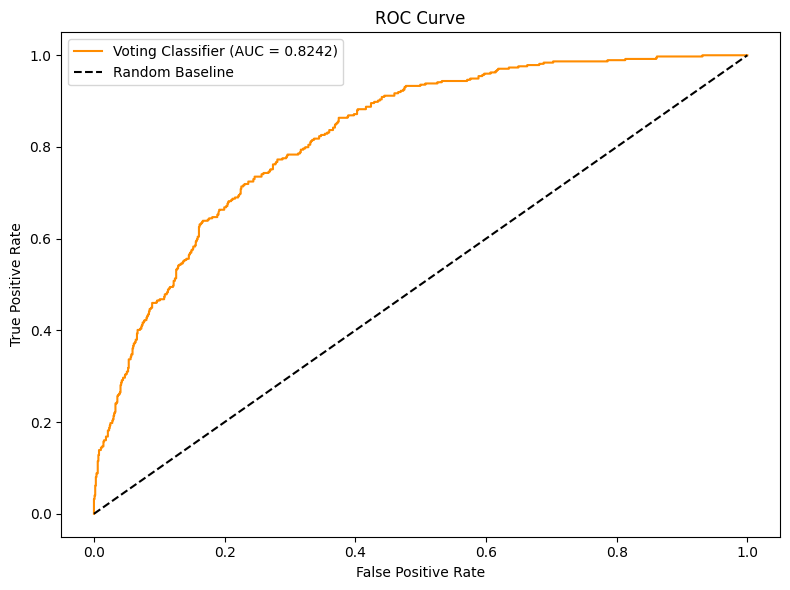

ROC-AUC Score: 0.8242


In [25]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Voting Classifier (AUC = {auc_score:.4f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()
print(f"ROC-AUC Score: {auc_score:.4f}")

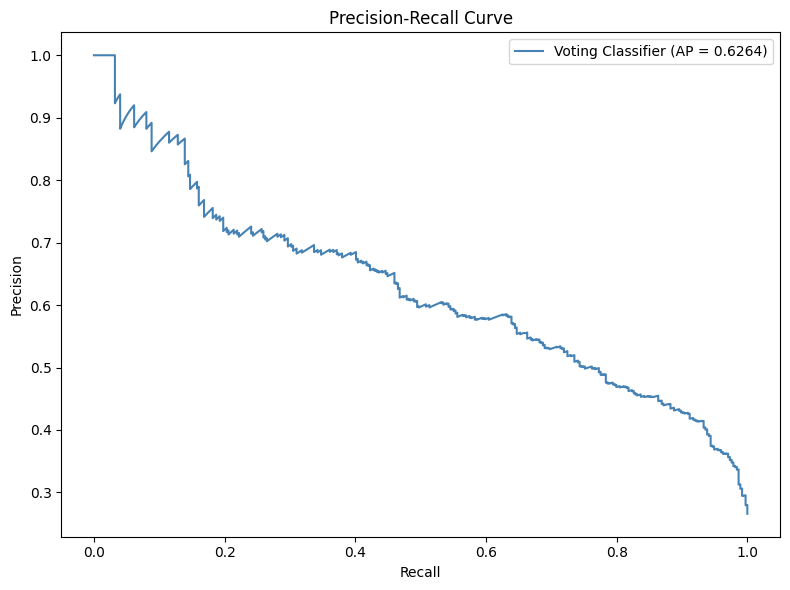

Average Precision Score: 0.6264


In [26]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Voting Classifier (AP = {avg_precision:.4f})', color='steelblue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Average Precision Score: {avg_precision:.4f}")

## 11. Save Model

In [27]:
path = Path.cwd().parent / 'Models'

joblib.dump(voting_clf, path / 'final_churn_model.pkl')
joblib.dump(label_encoders, path / 'label_encoders.pkl')
print("Model and encoders saved successfully.")

Model and encoders saved successfully.


In [28]:
# Load and verify
model = joblib.load(path/'final_churn_model.pkl')
label_encoders = joblib.load(path/'label_encoders.pkl')
print("Model loaded successfully:", type(model))

Model loaded successfully: <class 'sklearn.ensemble._voting.VotingClassifier'>


In [29]:
xgb_model = grid_xgb.best_estimator_
xgb_model.fit(X_train_smote, y_train_smote)

# SHAP TreeExplainer — fast and exact for tree-based models
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

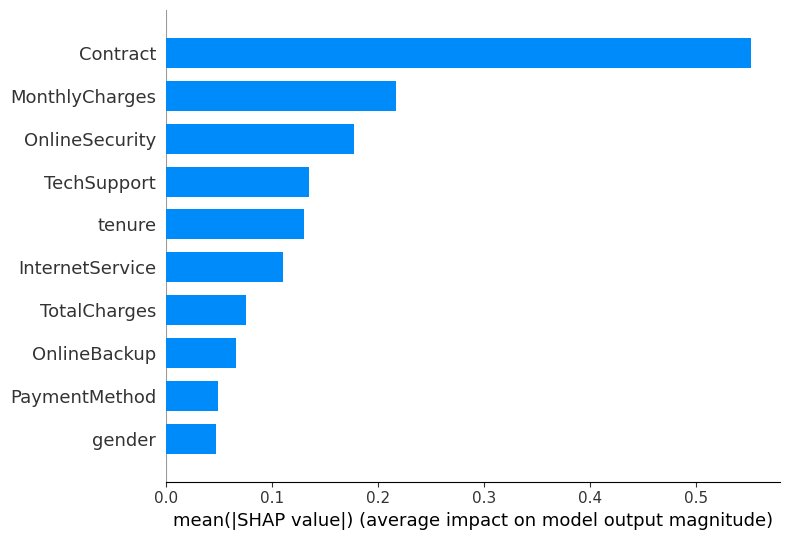

In [30]:
# Global feature importance — which features drive churn predictions overall
shap.summary_plot(shap_values, X_test, feature_names=important_features, plot_type='bar')

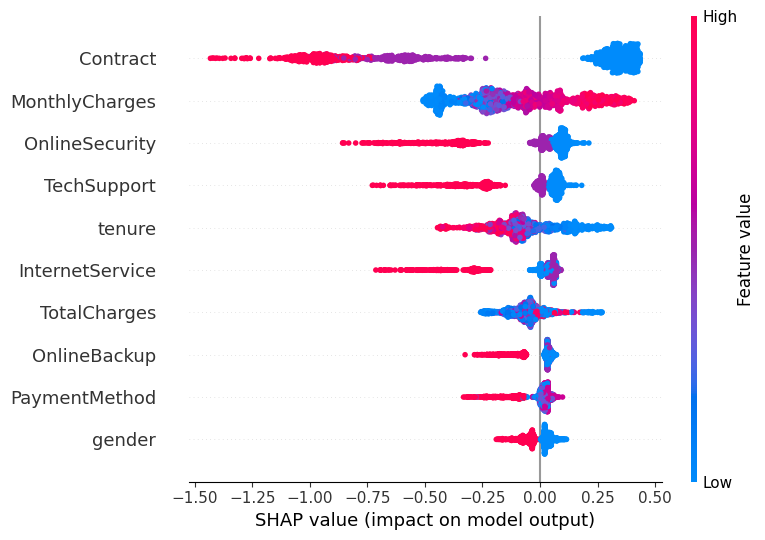

In [31]:
shap.summary_plot(shap_values, X_test, feature_names=important_features)

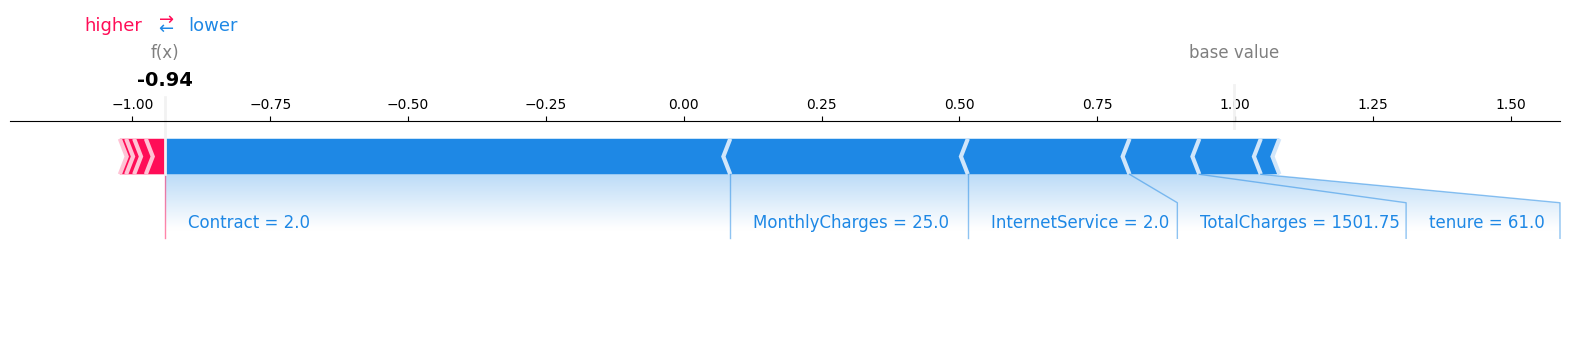

In [32]:
customer_index = 0

shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[customer_index],
    X_test.iloc[customer_index],
    feature_names=important_features,
    matplotlib=True
)